In [1]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler, Binarizer
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

filename = '/gdrive/My Drive/ML/data/pima-indians-diabetes.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'Outcome']

# 1. Number of times pregnant(임신회수)
# 2. Plasma glucose concentration a 2 hours in an oral glucose tolerance test: 글루코즈
# 3. Diastolic blood pressure (mm Hg) : 혈압
# 4. Triceps skin fold thickness (mm) : 팔근육량
# 5. 2-Hour serum insulin (mu U/ml) : 인슐린
# 6. Body mass index (weight in kg/(height in m)^2): BMI
# 7. Diabetes pedigree function : 가족력
# 8. Age (years) : 나이
# 9. Class variable (0 or 1)

diabetes_data = pd.read_csv(filename, names=names)
print(diabetes_data['Outcome'].value_counts())
diabetes_data.head(5)

Outcome
0    500
1    268
Name: count, dtype: int64


,preg,plas,pres,skin,test,mass,pedi,age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


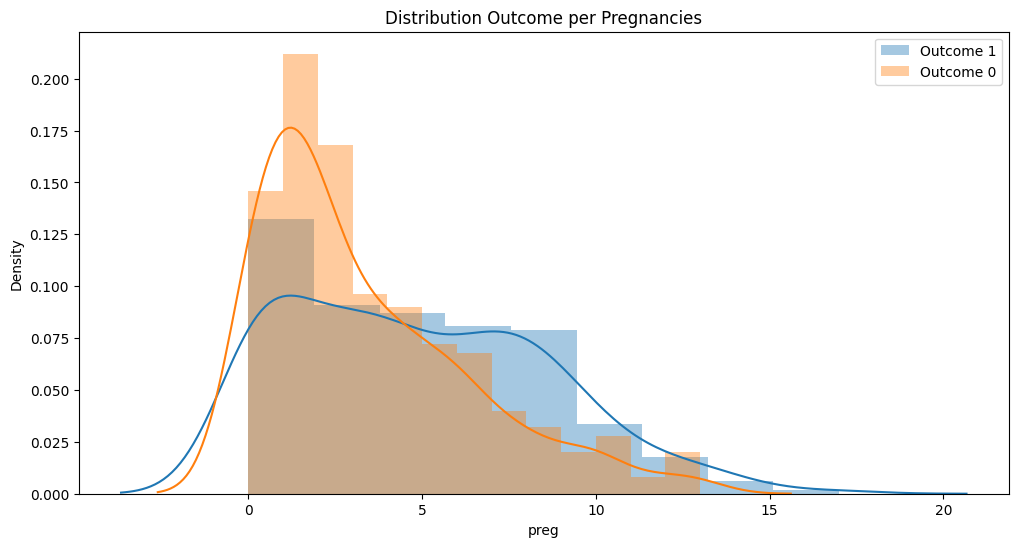

In [3]:
import  matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
plt.title("Distribution Outcome per Pregnancies")
sns.distplot(diabetes_data[diabetes_data['Outcome']==1]['preg'], label='Outcome 1')
sns.distplot(diabetes_data[diabetes_data['Outcome']==0]['preg'], label='Outcome 0')
plt.legend()

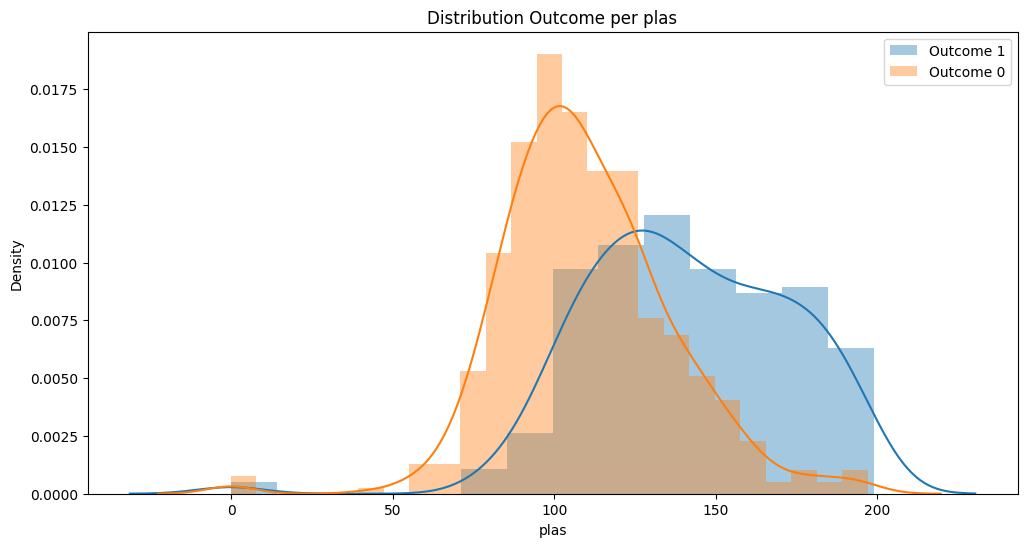

In [ ]:
plt.figure(figsize=(12,6))
plt.title("Distribution Outcome per plas")
sns.distplot(diabetes_data[diabetes_data['Outcome']==1]['plas'], label='Outcome 1')
sns.distplot(diabetes_data[diabetes_data['Outcome']==0]['plas'], label='Outcome 0')
plt.legend()

In [4]:
zero_features = ['pres','skin','test', 'mass']
mean_zero_features = diabetes_data[zero_features].mean()
diabetes_data[zero_features] = diabetes_data[zero_features].replace(0, mean_zero_features)
# diabetes_data['test'] = np.log(diabetes_data['test'])
# diabetes_data['pedi'] = np.log(diabetes_data['pedi'])

In [5]:
sns.countplot('Outcome',data=diabetes_data)

TypeError: countplot() got multiple values for argument 'data'

In [6]:
def model_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred)

    print('오차행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC:{4:.4f}'
          .format(accuracy, precision, recall, f1, roc_auc))




In [7]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [8]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

oversample = RandomOverSampler(sampling_strategy='minority')
X_over, y_over = oversample.fit_resample(X,y)

In [9]:
X_over.shape, X.shape

((1000, 8), (768, 8))

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_over, y_over, test_size=0.2)

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

model_eval(y_test, pred)

오차행렬
[[77 22]
 [21 80]]
정확도: 0.7850, 정밀도: 0.7843, 재현율: 0.7921, F1: 0.7882, AUC:0.7849


In [11]:
pred_proba

array([0.36538657, 0.39455733, 0.85904303, 0.66971567, 0.17699586,
       0.67476687, 0.32633172, 0.06098199, 0.47233541, 0.9634737 ,
       0.32618986, 0.19255575, 0.77822506, 0.11749927, 0.08408447,
       0.93443011, 0.74818969, 0.35611987, 0.41367164, 0.29778186,
       0.39661459, 0.87474173, 0.84296129, 0.53067411, 0.15322307,
       0.42755127, 0.58417396, 0.34752721, 0.53193555, 0.64749244,
       0.63173358, 0.72054818, 0.9615114 , 0.8545902 , 0.70923662,
       0.06858877, 0.5064833 , 0.39924961, 0.90115211, 0.87981546,
       0.67704667, 0.14111626, 0.67671912, 0.85251629, 0.14759677,
       0.25522741, 0.32396347, 0.20333361, 0.06063919, 0.44820635,
       0.96649918, 0.60706058, 0.93043899, 0.29730101, 0.85904303,
       0.90115211, 0.43643839, 0.79678595, 0.70385808, 0.91732551,
       0.08917779, 0.83441983, 0.72146669, 0.70829049, 0.05326831,
       0.42124327, 0.24316879, 0.16773126, 0.72054818, 0.48331453,
       0.98549726, 0.36376634, 0.94019529, 0.47535115, 0.62777

In [12]:
def dec_by_prob(y_test, pred_proba, criteria):
    import numpy as np
    pred = np.where(pred_proba > criteria, 1, 0)
    return pred

pred = dec_by_prob(y_test, pred_proba, 0.4)
model_eval(y_test, pred)

오차행렬
[[67 32]
 [ 7 94]]
정확도: 0.8050, 정밀도: 0.7460, 재현율: 0.9307, F1: 0.8282, AUC:0.8037


array([[<Axes: xlabel='skin', ylabel='skin'>,
        <Axes: xlabel='test', ylabel='skin'>],
       [<Axes: xlabel='skin', ylabel='test'>,
        <Axes: xlabel='test', ylabel='test'>]], dtype=object)

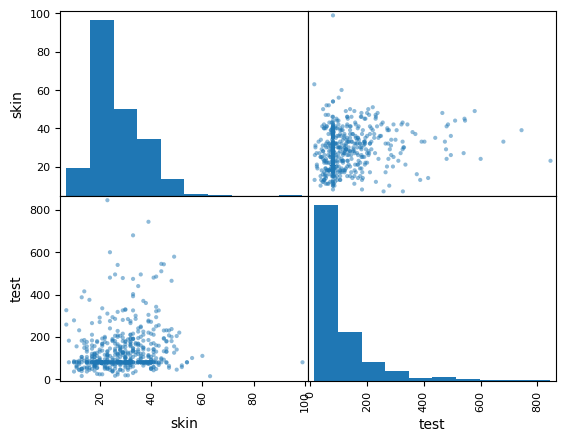

In [ ]:
pd.plotting.scatter_matrix(diabetes_data[['skin', 'test']])

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)
pred = model.predict(X_test)
model_eval(y_test, pred)

오차행렬
[[80 31]
 [13 76]]
정확도: 0.7800, 정밀도: 0.7103, 재현율: 0.8539, F1: 0.7755, AUC:0.7873


In [ ]:
n_trees = 100
model = RandomForestClassifier(n_estimators=n_trees)
model.fit(X_train, y_train)
pred = model.predict(X_test)
model_eval(y_test, pred)

오차행렬
[[84 27]
 [ 8 81]]
정확도: 0.8250, 정밀도: 0.7500, 재현율: 0.9101, F1: 0.8223, AUC:0.8334


In [ ]:
model = AdaBoostClassifier(n_estimators=n_trees)
model.fit(X_train, y_train)
pred = model.predict(X_test)
model_eval(y_test, pred)

오차행렬
[[87 24]
 [18 71]]
정확도: 0.7900, 정밀도: 0.7474, 재현율: 0.7978, F1: 0.7717, AUC:0.7908


In [ ]:
model = GradientBoostingClassifier(n_estimators=n_trees)
model.fit(X_train, y_train)
pred = model.predict(X_test)
model_eval(y_test, pred)

오차행렬
[[77 34]
 [14 75]]
정확도: 0.7600, 정밀도: 0.6881, 재현율: 0.8427, F1: 0.7576, AUC:0.7682


In [ ]:
model = XGBClassifier(n_estimators=n_trees)
model.fit(X_train, y_train)
pred = model.predict(X_test)
model_eval(y_test, pred)

오차행렬
[[85 26]
 [ 9 80]]
정확도: 0.8250, 정밀도: 0.7547, 재현율: 0.8989, F1: 0.8205, AUC:0.8323


In [ ]:
model = LGBMClassifier(n_estimators=n_trees)
model.fit(X_train, y_train)
pred = model.predict(X_test)
model_eval(y_test, pred)

[LightGBM] [Info] Number of positive: 411, number of negative: 389
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 752
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513750 -> initscore=0.055014
[LightGBM] [Info] Start training from score 0.055014
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [ ]:
model.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': None,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [ ]:
parms = {'boosting_type': 'gbdt',
 'colsample_bytree': 1,
 'learning_rate': 0.03,
 'n_estimators': 300,
 'num_leaves': 31,
 'objective': 'binary',
 'reg_alpha': 0,
 'reg_lambda': 0,
 'subsample': 0.7}

In [ ]:
model = LGBMClassifier(**parms)
model.fit(X_train, y_train)
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:, 1]
model_eval(y_test, pred)

[LightGBM] [Info] Number of positive: 411, number of negative: 389
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 752
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513750 -> initscore=0.055014
[LightGBM] [Info] Start training from score 0.055014
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [ ]:
from sklearn.model_selection import GridSearchCV
clf = LGBMClassifier()
param_grid = {
    'learning_rate': [0.005, 0.01, 0.02, 0.03, 0.05, 0.1],
    'n_estimators': [100,300, 500],
    'num_leaves': [31, 40, 50], # large num_leaves helps improve accuracy but might lead to over-fitting
    'boosting_type' : ['gbdt', 'dart'], # for better accuracy -> try dart
    'objective' : ['binary'],
    'colsample_bytree' : [0.8, 1],
    'subsample' : [0.7,0.75],
    'reg_alpha' : [0, 1,1.2],
    'reg_lambda' : [0, 1,1.2],
    }

gsearch = GridSearchCV(estimator=clf, param_grid=param_grid, n_jobs=2)
gsearch.fit(X_train, y_train)

In [ ]:
gsearch.best_params_

{'boosting_type': 'gbdt',
 'colsample_bytree': 1,
 'learning_rate': 0.03,
 'n_estimators': 500,
 'num_leaves': 31,
 'objective': 'binary',
 'reg_alpha': 1,
 'reg_lambda': 0,
 'subsample': 0.7}

In [ ]:
model = gsearch.best_estimator_  # 최적의 파라미터로 모델 생성
model.fit(X_train, y_train)
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:, 1]
model_eval(y_test, pred)

오차행렬
[[ 76  15]
 [  9 100]]
정확도: 0.8800, 정밀도: 0.8696, 재현율: 0.9174, F1: 0.8929, AUC:0.8763
